In [1]:
import pandas as pd

In [2]:
csv = pd.read_csv('/home/fsoto/Documents/LCsSSL/wandb_csv/embeddings_ablation_reduced_size_factor.csv')

In [3]:
columns = ['model.lc_net.time_encoder.use_sinusoidal',
      'model.lc_net.time_encoder.use_conv_mag',
      'model.lc_net.time_encoder.use_mag_diff',
      'model.lc_net.time_encoder.use_time_diff',
      'model.lc_net.time_encoder.use_rate',
      'model.lc_net.time_encoder.use_band_embedding',
      'model.lc_net.time_encoder.use_abs_time_mlp',
      'model.lc_net.time_encoder.use_abs_mag_mlp',
      'model.lc_net.time_encoder.fusion_strategy',
      'model.lc_net.time_encoder.mlp_layers',
      'model.lc_net.num_harmonics',
      'model/params/total',
      'model.lc_net.time_encoder.reduced_size_factor',
      'val/f1',
      'val/loss',
      'data.split']

In [4]:
csv = csv[columns].fillna(False)

/tmp/ipykernel_2037091/4100446943.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  csv = csv[columns].fillna(False)


In [8]:
# Group by all time_encoder columns and calculate mean and std for val/f1
encoder_cols = [
    'model.lc_net.time_encoder.use_sinusoidal',
    'model.lc_net.time_encoder.use_conv_mag',
    'model.lc_net.time_encoder.use_mag_diff',
    'model.lc_net.time_encoder.use_time_diff',
    'model.lc_net.time_encoder.use_rate',
    'model.lc_net.time_encoder.use_band_embedding',
    'model.lc_net.time_encoder.use_abs_time_mlp',
    'model.lc_net.time_encoder.use_abs_mag_mlp',
    'model.lc_net.time_encoder.fusion_strategy',
    'model.lc_net.time_encoder.mlp_layers',
    'model.lc_net.num_harmonics',
    'model.lc_net.time_encoder.reduced_size_factor',
    'model/params/total',
]
grouped = csv.groupby(encoder_cols)



In [9]:
grouped_mean = grouped['val/f1'].agg(['mean', 'std', 'count']).reset_index().sort_values(by='mean', ascending=False)

In [11]:
grouped_mean

,model.lc_net.time_encoder.use_sinusoidal,model.lc_net.time_encoder.use_conv_mag,model.lc_net.time_encoder.use_mag_diff,model.lc_net.time_encoder.use_time_diff,model.lc_net.time_encoder.use_rate,model.lc_net.time_encoder.use_band_embedding,model.lc_net.time_encoder.use_abs_time_mlp,model.lc_net.time_encoder.use_abs_mag_mlp,model.lc_net.time_encoder.fusion_strategy,model.lc_net.time_encoder.mlp_layers,model.lc_net.num_harmonics,model.lc_net.time_encoder.reduced_size_factor,model/params/total,mean,std,count
1,False,True,False,True,True,False,False,False,mlp,2,False,1.0,891401,0.830736,0.005992,5
2,False,True,False,True,True,False,False,False,mlp,2,False,2.0,685065,0.830094,0.009086,5
0,False,True,False,True,True,False,False,False,mlp,2,False,0.5,1648137,0.824684,0.008253,5


In [12]:
from mlxtend.evaluate import permutation_test
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to get F1 scores for a specific configuration
def get_f1_scores_for_config(config_row):
    """Get all F1 scores for a specific encoder configuration"""
    config_values = config_row[encoder_cols].to_dict()
    
    # Filter original data to match this configuration
    mask = True
    for col, val in config_values.items():
        mask = mask & (csv[col] == val)
    
    matching_scores = csv[mask]['val/f1'].values
    return matching_scores

print(f"Total number of unique configurations: {len(grouped_mean)}")
print("Starting pairwise permutation tests...")

Total number of unique configurations: 3
Starting pairwise permutation tests...


In [13]:
# Perform pairwise permutation tests between configurations
# Start with top 10 configurations to keep computation manageable
top_configs = grouped_mean 
n_configs = len(top_configs)

results = []

print(f"Performing {n_configs * (n_configs - 1) // 2} pairwise comparisons...")

for i in range(n_configs):
    for j in range(i + 1, n_configs):
        config_i = top_configs.iloc[i]
        config_j = top_configs.iloc[j]
        
        # Get F1 scores for each configuration
        scores_i = get_f1_scores_for_config(config_i)
        scores_j = get_f1_scores_for_config(config_j)
        
        # Only perform test if we have enough samples
        if len(scores_i) > 1 and len(scores_j) > 1:
            # Perform permutation test
            p_value = permutation_test(scores_i, scores_j,
                                     method='approximate',
                                     num_rounds=10000,
                                     seed=0,
                                     func='x_mean > y_mean')
            
            # Calculate effect size (Cohen's d)
            pooled_std = np.sqrt((np.var(scores_i) + np.var(scores_j)) / 2)
            effect_size = (np.mean(scores_i) - np.mean(scores_j)) / pooled_std if pooled_std > 0 else 0
            
            results.append({
                'config_1': i+1,
                'config_2': j+1,
                'mean_f1_1': config_i['mean'],
                'mean_f1_2': config_j['mean'],
                'std_f1_1': config_i['std'],
                'std_f1_2': config_j['std'],
                'p_value': p_value,
                'effect_size': effect_size,
                'significant': p_value < 0.05,
                'n_samples_1': len(scores_i),
                'n_samples_2': len(scores_j)
            })
            
            # Print progress for every 10 comparisons
            if len(results) % 10 == 0:
                print(f"Completed {len(results)} comparisons...")

# Convert results to DataFrame
comparison_results = pd.DataFrame(results)
print(f"\nCompleted all {len(comparison_results)} pairwise comparisons")
print(f"Significant differences found: {comparison_results['significant'].sum()}")

# Display summary
print("\nPairwise Comparison Results (sorted by p-value):")
print(comparison_results.sort_values('p_value'))

Performing 3 pairwise comparisons...

Completed all 3 pairwise comparisons
Significant differences found: 0

Pairwise Comparison Results (sorted by p-value):
   config_1  config_2  mean_f1_1  mean_f1_2  std_f1_1  std_f1_2   p_value  \
1         1         3   0.830736   0.824684  0.005992  0.008253  0.113189   
2         2         3   0.830094   0.824684  0.009086  0.008253  0.177882   
0         1         2   0.830736   0.830094  0.005992  0.009086  0.436356   

   effect_size  significant  n_samples_1  n_samples_2  
1     0.938291        False            5            5  
2     0.696934        False            5            5  
0     0.093222        False            5            5  


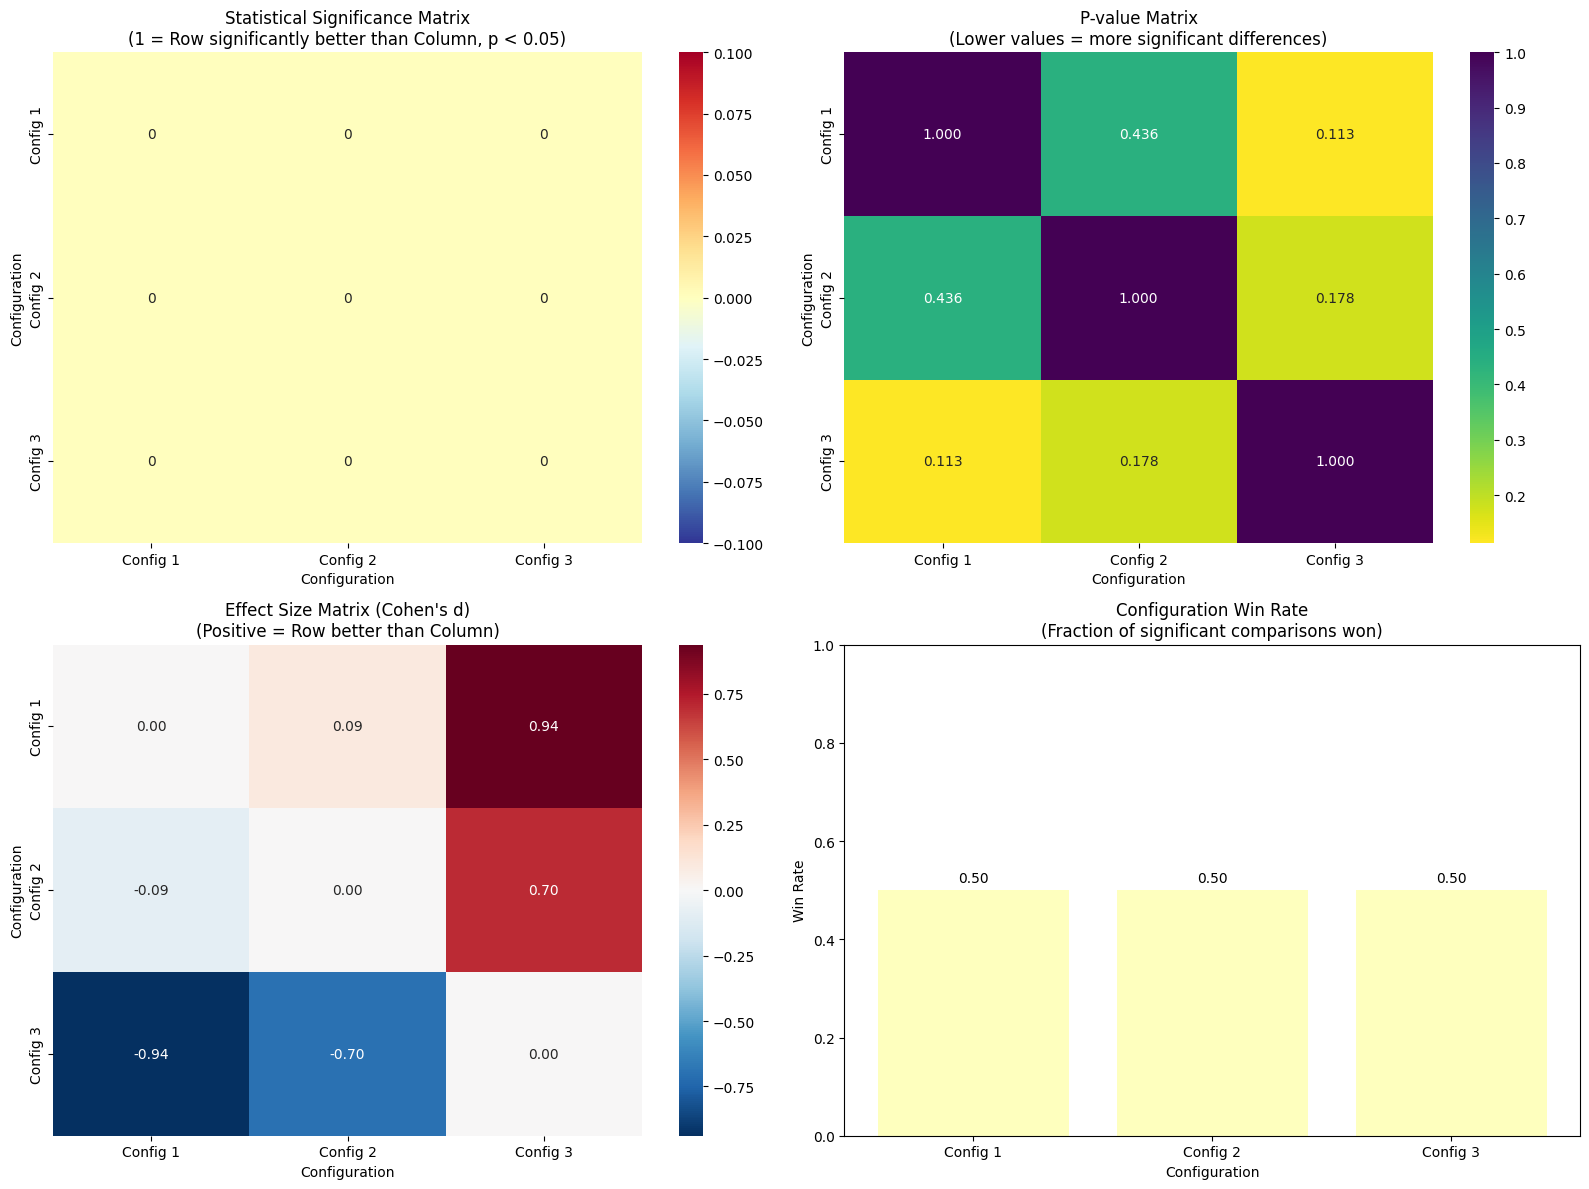


Configuration Performance Summary:
   config   mean_f1  wins  losses  win_rate
0       1  0.830736     0       0       0.5
1       2  0.830094     0       0       0.5
2       3  0.824684     0       0       0.5


In [14]:
# Create confusion matrix for statistical comparisons
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Significance matrix
sig_matrix = np.zeros((n_configs, n_configs))
p_value_matrix = np.ones((n_configs, n_configs))
effect_matrix = np.zeros((n_configs, n_configs))

for _, row in comparison_results.iterrows():
    i, j = int(row['config_1']) - 1, int(row['config_2']) - 1
    
    # Fill significance matrix (1 if config i significantly better than config j)
    if row['significant']:
        if row['mean_f1_1'] > row['mean_f1_2']:
            sig_matrix[i, j] = 1
        else:
            sig_matrix[j, i] = 1
    
    # Fill p-value matrix (symmetric)
    p_value_matrix[i, j] = row['p_value']
    p_value_matrix[j, i] = row['p_value']
    
    # Fill effect size matrix
    effect_matrix[i, j] = row['effect_size']
    effect_matrix[j, i] = -row['effect_size']

# Plot significance matrix
sns.heatmap(sig_matrix, 
            annot=True, 
            fmt='.0f', 
            cmap='RdYlBu_r',
            ax=ax1,
            xticklabels=[f'Config {i+1}' for i in range(n_configs)],
            yticklabels=[f'Config {i+1}' for i in range(n_configs)])
ax1.set_title('Statistical Significance Matrix\n(1 = Row significantly better than Column, p < 0.05)')
ax1.set_xlabel('Configuration')
ax1.set_ylabel('Configuration')

# Plot p-value matrix
sns.heatmap(p_value_matrix,
            annot=True,
            fmt='.3f',
            cmap='viridis_r',
            ax=ax2,
            xticklabels=[f'Config {i+1}' for i in range(n_configs)],
            yticklabels=[f'Config {i+1}' for i in range(n_configs)])
ax2.set_title('P-value Matrix\n(Lower values = more significant differences)')
ax2.set_xlabel('Configuration')
ax2.set_ylabel('Configuration')

# Plot effect size matrix
sns.heatmap(effect_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            ax=ax3,
            xticklabels=[f'Config {i+1}' for i in range(n_configs)],
            yticklabels=[f'Config {i+1}' for i in range(n_configs)])
ax3.set_title('Effect Size Matrix (Cohen\'s d)\n(Positive = Row better than Column)')
ax3.set_xlabel('Configuration')
ax3.set_ylabel('Configuration')

# Performance summary bar plot
config_performance = []
for i in range(n_configs):
    config_data = top_configs.iloc[i]
    wins = sig_matrix[i, :].sum()  # How many configs this one beats
    losses = sig_matrix[:, i].sum()  # How many beat this one
    
    config_performance.append({
        'config': i+1,
        'mean_f1': config_data['mean'],
        'wins': int(wins),
        'losses': int(losses),
        'win_rate': wins / (wins + losses) if (wins + losses) > 0 else 0.5
    })

perf_df = pd.DataFrame(config_performance)

# Bar plot
bars = ax4.bar(range(len(perf_df)), perf_df['win_rate'], 
               color=plt.cm.RdYlGn(perf_df['win_rate']))
ax4.set_title('Configuration Win Rate\n(Fraction of significant comparisons won)')
ax4.set_xlabel('Configuration')
ax4.set_ylabel('Win Rate')
ax4.set_xticks(range(len(perf_df)))
ax4.set_xticklabels([f'Config {i+1}' for i in range(len(perf_df))])
ax4.set_ylim(0, 1)

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars, perf_df['win_rate'])):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{rate:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nConfiguration Performance Summary:")
print(perf_df.sort_values('win_rate', ascending=False))

In [15]:
# Detailed analysis of significant differences
print("Detailed Analysis of Significant Differences:")
print("=" * 60)

significant_comparisons = comparison_results[comparison_results['significant'] == True]

if len(significant_comparisons) > 0:
    print(f"Found {len(significant_comparisons)} significant differences out of {len(comparison_results)} total comparisons")
    print(f"Significance rate: {len(significant_comparisons)/len(comparison_results)*100:.1f}%\n")
    
    # Sort by effect size magnitude
    significant_comparisons_sorted = significant_comparisons.reindex(
        significant_comparisons['effect_size'].abs().sort_values(ascending=False).index
    )
    
    print("Top 5 Most Significant Differences (by effect size):")
    for i, (_, comp) in enumerate(significant_comparisons_sorted.head(5).iterrows()):
        config_i_idx = int(comp['config_1']) - 1
        config_j_idx = int(comp['config_2']) - 1
        config_i = top_configs.iloc[config_i_idx]
        config_j = top_configs.iloc[config_j_idx]
        
        print(f"\n{i+1}. Config {comp['config_1']} vs Config {comp['config_2']}:")
        print(f"   F1 scores: {comp['mean_f1_1']:.4f} vs {comp['mean_f1_2']:.4f}")
        print(f"   Difference: {comp['mean_f1_1'] - comp['mean_f1_2']:+.4f}")
        print(f"   P-value: {comp['p_value']:.6f}")
        print(f"   Effect size: {comp['effect_size']:+.4f}")
        print(f"   Sample sizes: {comp['n_samples_1']} vs {comp['n_samples_2']}")
        
        # Show configuration differences
        print("   Configuration differences:")
        for col in encoder_cols:
            val_i = config_i[col]
            val_j = config_j[col]
            if val_i != val_j:
                print(f"     {col.split('.')[-1]}: {val_i} vs {val_j}")
    
    # Summary statistics
    print(f"\nSummary Statistics for Significant Comparisons:")
    print(f"Mean p-value: {significant_comparisons['p_value'].mean():.6f}")
    print(f"Mean |effect size|: {significant_comparisons['effect_size'].abs().mean():.4f}")
    print(f"Range of effect sizes: {significant_comparisons['effect_size'].min():.4f} to {significant_comparisons['effect_size'].max():.4f}")

else:
    print("No statistically significant differences found between any configurations.")
    print("This could indicate:")
    print("1. All configurations perform similarly")
    print("2. Sample sizes are too small to detect differences")
    print("3. Variability within configurations is too high")

Detailed Analysis of Significant Differences:
No statistically significant differences found between any configurations.
This could indicate:
1. All configurations perform similarly
2. Sample sizes are too small to detect differences
3. Variability within configurations is too high


Configuration Labels:
Config 1: CM+TD+R+FMLP 2L
Config 2: CM+TD+R+FMLP 2L
Config 3: CM+TD+R+FMLP 2L


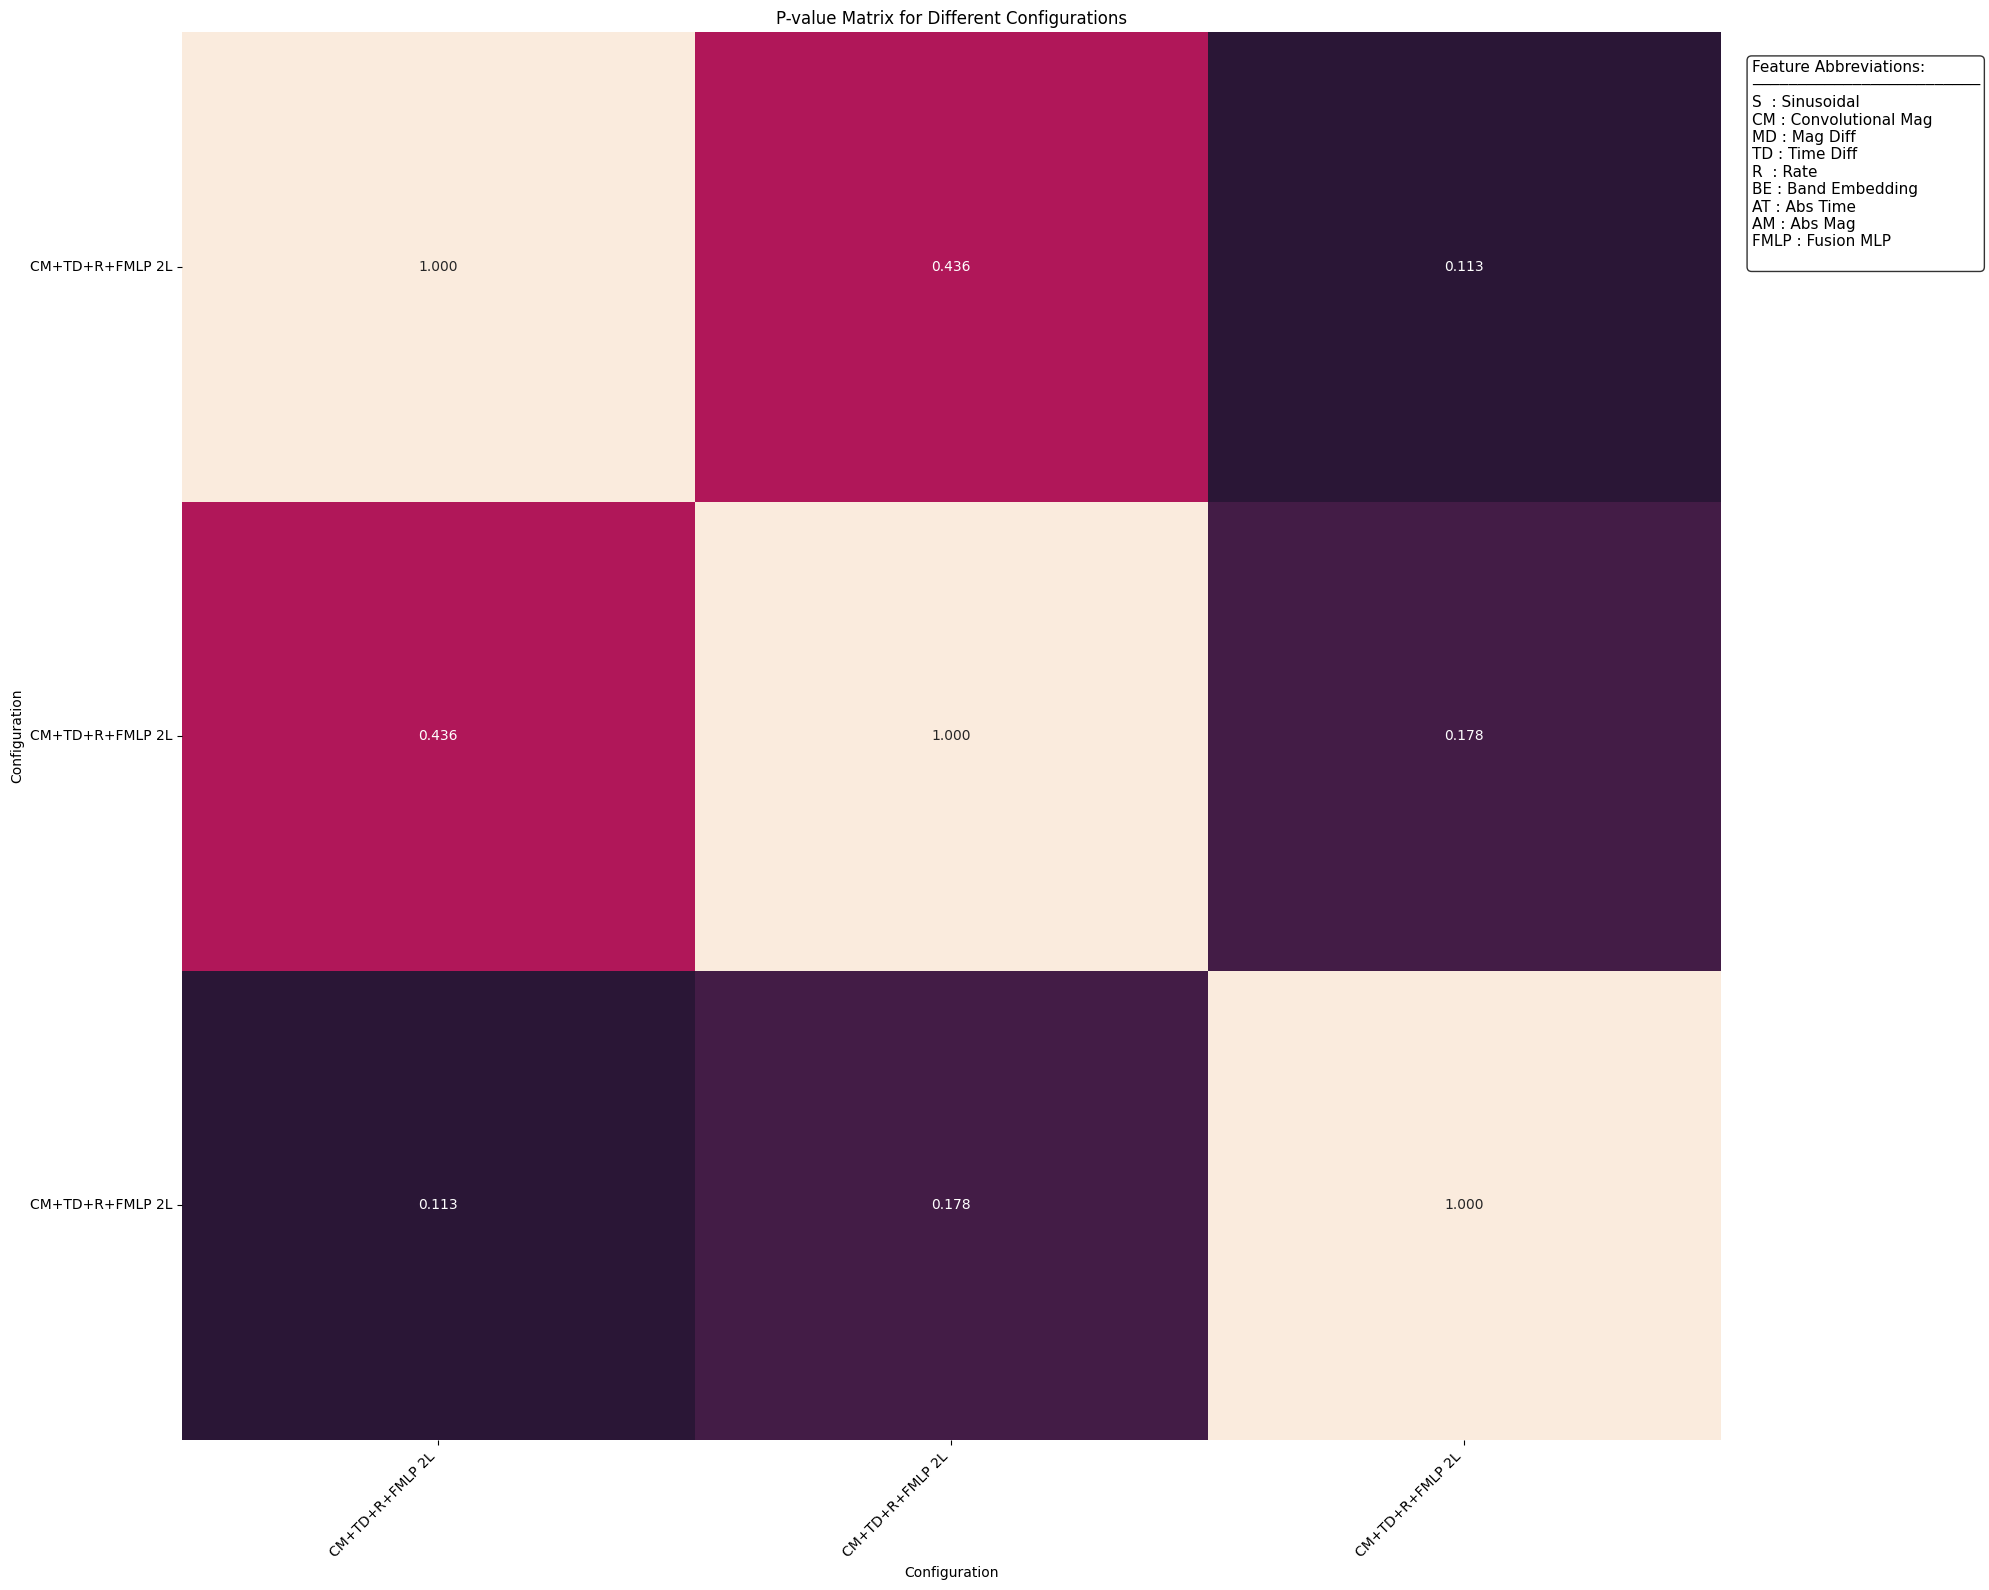

In [16]:
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import numpy as np

# Create meaningful configuration names based on True features
def create_config_name(config_row):
    """Create a descriptive name for a configuration based on enabled features"""
    true_features = []
    
    # Feature abbreviation mapping
    feature_abbrev = {
        'model.lc_net.time_encoder.use_sinusoidal': 'S',
        'model.lc_net.time_encoder.use_conv_mag': 'CM',
        'model.lc_net.time_encoder.use_mag_diff': 'MD',
        'model.lc_net.time_encoder.use_time_diff': 'TD',
        'model.lc_net.time_encoder.use_rate': 'R',
        'model.lc_net.time_encoder.use_band_embedding': 'BE',
        'model.lc_net.time_encoder.use_abs_time_mlp': 'AT',
        'model.lc_net.time_encoder.use_abs_mag_mlp': 'AM',
        'model.lc_net.num_harmonics': 'TimeFilm'
    }


    # Check boolean features
    boolean_cols = [col for col in encoder_cols if col.startswith('model.lc_net.time_encoder.use_')]
    for col in boolean_cols:
        if config_row[col] == True:
            abbrev = feature_abbrev.get(col, col.replace('model.lc_net.time_encoder.use_', ''))
            true_features.append(abbrev)
    
    # Add non-boolean features if they're not default
    fusion_strategy = config_row['model.lc_net.time_encoder.fusion_strategy']
    mlp_layers = config_row['model.lc_net.time_encoder.mlp_layers']
    timefilm = config_row['model.lc_net.num_harmonics'] > 0
    # Add fusion strategy and MLP layers in compact format
    if fusion_strategy == 'mlp':
        true_features.append(f"F{fusion_strategy.upper()} {int(mlp_layers)}L")
    if timefilm:
        true_features.append("TimeFilm")


    if len(true_features) == 0:
        return "No_Features"
    else:
        return "+".join(true_features)

# Create configuration labels
config_labels = []
for i in range(n_configs):
    config = top_configs.iloc[i]
    label = create_config_name(config)
    config_labels.append(label)

print("Configuration Labels:")
for i, label in enumerate(config_labels):
    print(f"Config {i+1}: {label}")

# Create a comprehensive visualization for the statistical analysis results
fig, axes = plt.subplots(1, figsize=(20, 16))

# Create a custom colormap that makes values < 0.05 green and others red scale
def create_pvalue_cmap():
    # Define colors: green for significant (< 0.05), red scale for non-significant
    colors = []
    n_bins = 256
    
    # First 5% of colormap (p < 0.05) - different shades of green
    for i in range(int(n_bins * 0.05)):
        intensity = i / (n_bins * 0.05)
        colors.append((0, 0.8 - 0.3 * intensity, 0))  # Dark to light green
    
    # Remaining 95% (p >= 0.05) - red scale
    for i in range(int(n_bins * 0.05), n_bins):
        intensity = (i - n_bins * 0.05) / (n_bins * 0.95)
        colors.append((1, 0.8 * intensity, 0.8 * intensity))  # Dark to light red
    
    return ListedColormap(colors)

custom_cmap = create_pvalue_cmap()
#add legend to the side
features_legend = {
    'S': 'Sinusoidal',
    'CM': 'Convolutional Mag',
    'MD': 'Mag Diff',
    'TD': 'Time Diff',
    'R': 'Rate',
    'BE': 'Band Embedding',
    'AT': 'Abs Time',
    'AM': 'Abs Mag',
    'FMLP': 'Fusion MLP',
}
# P-value heatmap with custom colormap and meaningful labels
sns.heatmap(p_value_matrix,
            annot=True,
            fmt='.3f',
            #cmap=custom_cmap,
            vmin=0,
            vmax=1,
            ax=axes,
            xticklabels=config_labels,
            yticklabels=config_labels,
            cbar=False)  # Remove colorbar
axes.set_title('P-value Matrix for Different Configurations')
axes.set_xlabel('Configuration')
axes.set_ylabel('Configuration')

# Rotate labels for better readability
plt.setp(axes.get_xticklabels(), rotation=45, ha='right')
plt.setp(axes.get_yticklabels(), rotation=0)

# Create a more presentable features legend
legend_text = "Feature Abbreviations:\n" + "─" * 25 + "\n"
for feature, desc in features_legend.items():
    legend_text += f"{feature:2} : {desc}\n"

# Add the legend as a text box
axes.text(1.02, 0.98, legend_text, 
          transform=axes.transAxes, 
          fontsize=11, 
          va='top', 
          ha='left',
          bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.show()



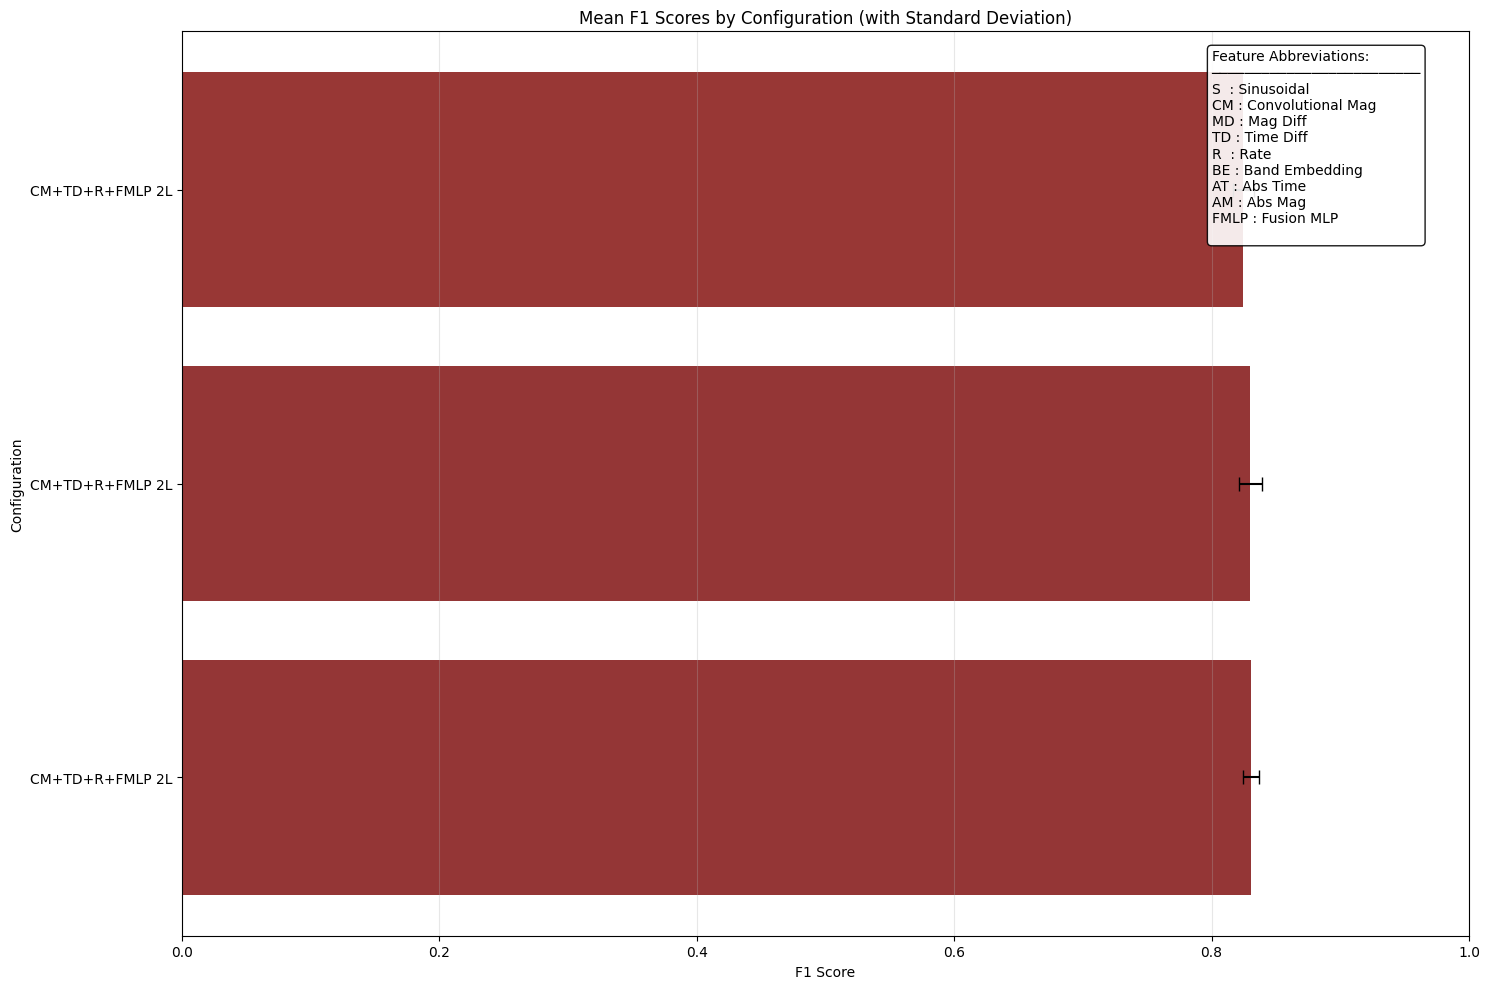

Configuration Performance Summary:
  Configuration  Mean_F1  Std_F1  Sample_Count
CM+TD+R+FMLP 2L    0.831   0.006             5
CM+TD+R+FMLP 2L    0.830   0.009             5
CM+TD+R+FMLP 2L    0.825   0.008             5


In [17]:
# Plot mean F1 scores with error bars (standard deviation)
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Extract mean and std values for plotting
mean_f1 = [top_configs.iloc[i]['mean'] for i in range(n_configs)]
std_f1 = [top_configs.iloc[i]['std'] for i in range(n_configs)]
count_samples = [top_configs.iloc[i]['count'] for i in range(n_configs)]

# Horizontal bar plot with error bars
bars = ax.barh(range(n_configs), mean_f1, xerr=std_f1, 
               capsize=5, alpha=0.8, 
               color=plt.cm.turbo([f/max(mean_f1) for f in mean_f1]))
ax.set_title('Mean F1 Scores by Configuration (with Standard Deviation)')
ax.set_ylabel('Configuration')
ax.set_xlabel('F1 Score')
ax.set_yticks(range(n_configs))
ax.set_yticklabels(config_labels)
ax.grid(True, alpha=0.3, axis='x')

# Set x-axis range to 1
ax.set_xlim(0, 1)

# Add the features legend
legend_text = "Feature Abbreviations:\n" + "─" * 25 + "\n"
for feature, desc in features_legend.items():
    legend_text += f"{feature:2} : {desc}\n"

# Add the legend as a text box inside the plot
ax.text(0.8, 0.98, legend_text, 
        transform=ax.transAxes, 
        fontsize=10, 
        va='top', 
        ha='left',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()

# Print summary statistics
print("Configuration Performance Summary:")
print("=" * 70)
summary_df = pd.DataFrame({
    'Configuration': config_labels,
    'Mean_F1': mean_f1,
    'Std_F1': std_f1,
    'Sample_Count': count_samples
}).round(3)

print(summary_df.to_string(index=False))

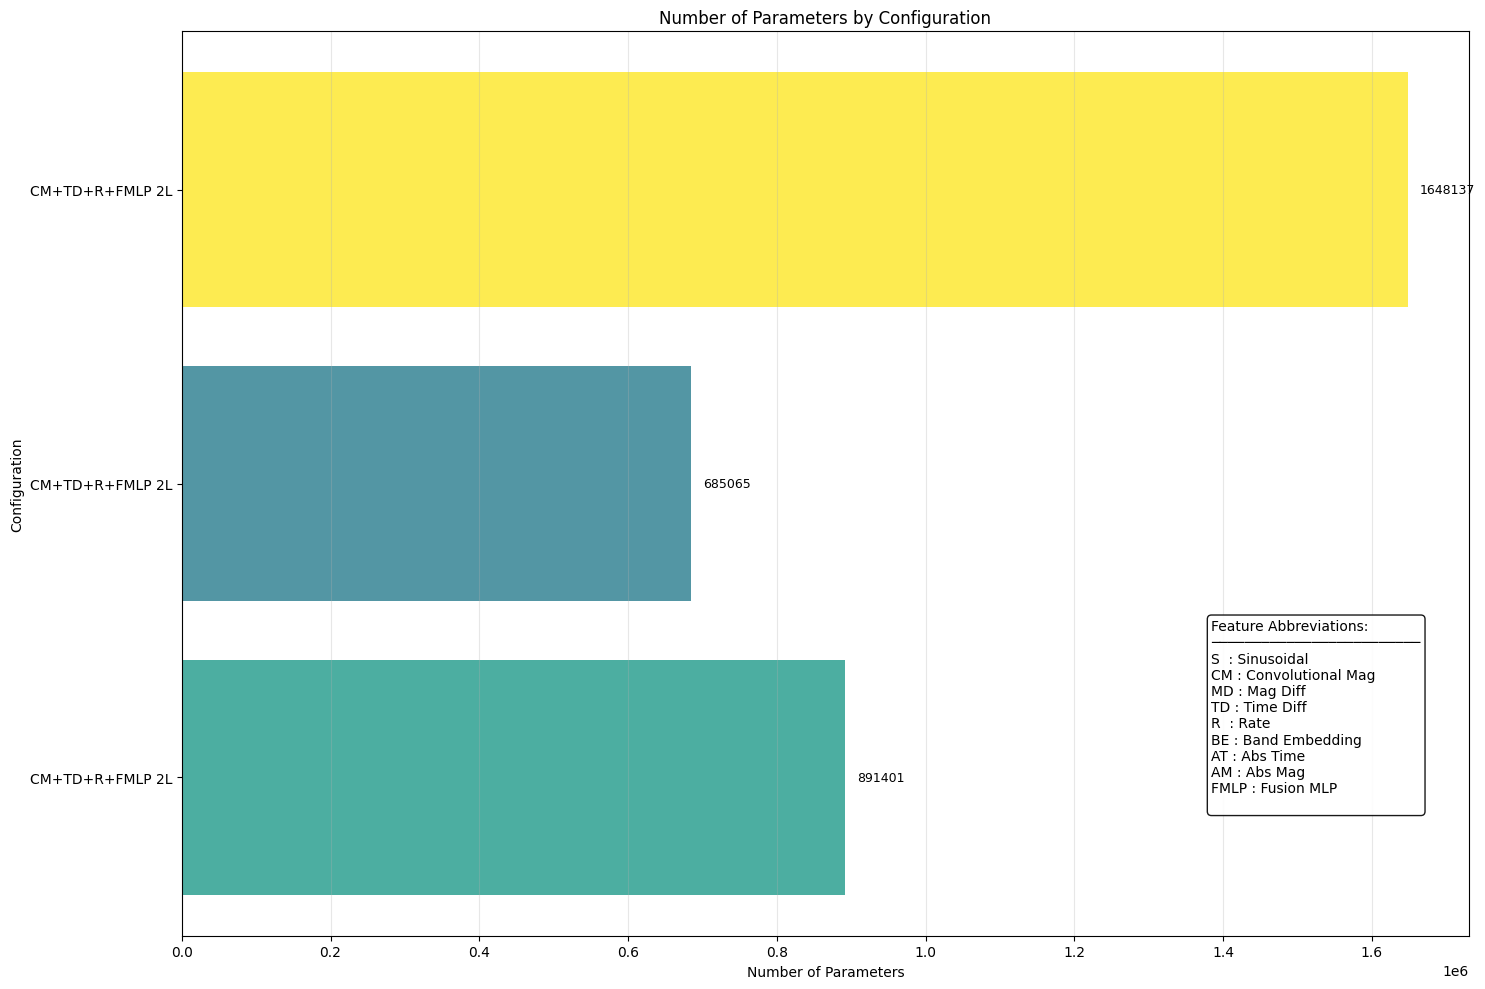

Parameter Count Summary:
  Configuration  Parameters  Mean_F1
CM+TD+R+FMLP 2L     1648137 0.824684
CM+TD+R+FMLP 2L      891401 0.830736
CM+TD+R+FMLP 2L      685065 0.830094

Correlation between Parameter Count and F1 Score: -0.9549


In [18]:
# Plot number of parameters by configuration
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Extract parameter counts for plotting
param_counts = [top_configs.iloc[i]['model/params/total'] for i in range(n_configs)]

# Horizontal bar plot for parameter counts
bars = ax.barh(range(n_configs), param_counts, 
               alpha=0.8, 
               color=plt.cm.viridis([p/max(param_counts) for p in param_counts]))
ax.set_title('Number of Parameters by Configuration')
ax.set_ylabel('Configuration')
ax.set_xlabel('Number of Parameters')
ax.set_yticks(range(n_configs))
ax.set_yticklabels(config_labels)
ax.grid(True, alpha=0.3, axis='x')

# Format x-axis to show parameter counts in a readable format
ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

# Add value labels on bars
for i, (bar, param_count) in enumerate(zip(bars, param_counts)):
    width = bar.get_width()
    ax.text(width + max(param_counts) * 0.01, bar.get_y() + bar.get_height()/2.,
            f'{param_count:.0f}', 
            ha='left', va='center', fontsize=9)

# Add the features legend
legend_text = "Feature Abbreviations:\n" + "─" * 25 + "\n"
for feature, desc in features_legend.items():
    legend_text += f"{feature:2} : {desc}\n"

# Add the legend as a text box inside the plot
ax.text(0.8, 0.35, legend_text, 
        transform=ax.transAxes, 
        fontsize=10, 
        va='top', 
        ha='left',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()

# Print parameter summary statistics
print("Parameter Count Summary:")
print("=" * 50)
param_summary_df = pd.DataFrame({
    'Configuration': config_labels,
    'Parameters': param_counts,
    'Mean_F1': mean_f1
}).sort_values('Parameters', ascending=False)

print(param_summary_df.to_string(index=False))

# Calculate correlation between parameters and F1 score
param_f1_corr = np.corrcoef(param_counts, mean_f1)[0, 1]
print(f"\nCorrelation between Parameter Count and F1 Score: {param_f1_corr:.4f}")